In [ ]:
# old final preprocessing
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

# --- Configurations & Maps (From your code) ---
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    # Punctuation/Noise
    '-', "''", "'",
    # Numbers & Timeline metadata
    '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end',
    # Entities & Locations
    'finnish', 'finland', 'helsinki', 'hel', 'nokia',
    # Corporate Boilerplate
    'oyj', 'oy', 'corpor', 'omx', 'group', 'compani',
    # Generic Verbs & English Stop Words
    'said', 'also', 'includ', 'accord', 'use', 'well',
    'per', 'part', 'would', 'base', 'provid'
}

PRESERVED_WORDS = {
    'good', 'bad', 'high', 'low', 'risk', 'profit', 'loss',
    'up', 'down', 'increase', 'decrease', 'increas', 'decreas',
    'strong', 'weak', 'better', 'worse', 'positive', 'negative',
    'stable', 'volatile', 'only', 'below', 'few', 'more',
    'no', 'not', 'nor', 'over', 'should', 'but'
}

english_defaults = set(stopwords.words('english'))

CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

STANDARD_STOPWORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "),
    (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)

    return text

# --- Strategy 1: Full Preprocessing ---
def preprocess_full(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)

    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)

    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)

    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)

    tokens = [word for word in text.split() if word not in CUSTOM_STOPWORDS]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens).strip()

# --- Strategy 2: Full Preprocessing + Masking ---
def preprocess_masked(text):
    # First, run the full strategy
    text = preprocess_full(text)

    # Then apply the specific semantic masks before returning
    text = re.sub(r'\b[a-z]{3}\d+\.?\d*[a-z]{1,2}\b', ' [MONEY_METRIC] ', text)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)

    # Clean up extra spaces
    return re.sub(r'\s+', ' ', text).strip()

# --- Strategy 3: Standard / Simple Preprocessing ---
def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Basic punctuation removal
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    # Standard NLTK stopwords (loses words like "up", "down", "no")
    filtered = [word for word in tokens if word not in STANDARD_STOPWORDS]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed).strip()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
# current final preprocessing

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

# --- Configurations & Maps ---
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    # Punctuation/Noise
    '-', "''", "'",
    # Numbers & Timeline metadata
    '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end',
    # Entities & Locations
    'finnish', 'finland', 'helsinki', 'hel', 'nokia',
    # Corporate Boilerplate
    'oyj', 'oy', 'corpor', 'omx', 'group', 'compani',
    # Generic Verbs & English Stop Words
    'said', 'also', 'includ', 'accord', 'use', 'well',
    'per', 'part', 'would', 'base', 'provid'
}

PRESERVED_WORDS = {
    'good', 'bad', 'high', 'low', 'risk', 'profit', 'loss',
    'up', 'down', 'increase', 'decrease', 'increas', 'decreas',
    'strong', 'weak', 'better', 'worse', 'positive', 'negative',
    'stable', 'volatile', 'only', 'below', 'few', 'more',
    'no', 'not', 'nor', 'over', 'should', 'but'
}

english_defaults = set(stopwords.words('english'))

CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

stemmer = PorterStemmer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "),
    (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)

    return text

# --- Isolated Core Cleaning Pipeline ---
def _normalize_text_pipeline(text):
    """Executes all structural cleanups, standardizations, and maps."""
    if not isinstance(text, str):
        return ""
    text = text.lower()

    # Extract phone numbers early
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)

    # Cleanups and Normalizations
    for reg, repl in EARLY_CLEANUP:
        text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items():
        text = word_regex.sub(num, text)

    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)

    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP):
        text = reg.sub(repl, text)

    # Re-insert compressed phone formats
    for p in phones:
        text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)

    return text

# --- Strategy 1: Full Preprocessing ---
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = [word for word in text.split() if word not in CUSTOM_STOPWORDS]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens).strip()

# --- Strategy 2: Full Preprocessing + Comprehensive Masking ---
def preprocess_masked(text):
    text = _normalize_text_pipeline(text)

    # 1. Mask Phone Numbers (e.g. +123456789)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE_MARKER] ', text)

    # 2. Mask Money / Currency metrics (e.g., usd100mn, eur5.5k, usd20)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY_METRIC] ', text)

    # 3. Mask Standalone Percentages (e.g., 10pct, 5.5pct)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)

    # 4. Mask Standardized Date Formats (Full ISO, Year-Month, Month-Month, Years)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)

    # 5. Mask Standardized Time Formats (e.g., 12:00am, 4:30pm)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME_MARKER] ', text)

    # 6. Mask Measurements and Physical Units (e.g., 50sqm, 10m, 5km, 20kg, 100g)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT_MARKER] ', text)

    # 7. Mask Generic Leftover Numbers (e.g., standalone quantities, counts)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER_MARKER] ', text)

    # Tokenize and Stem standard vocabulary while shielding our new placeholders
    tokens = text.split()
    processed_tokens = []

    mask_placeholders = {
        '[PHONE_MARKER]', '[MONEY_METRIC]', '[PERCENT_METRIC]',
        '[DATE_MARKER]', '[TIME_MARKER]', '[MEASUREMENT_MARKER]', '[NUMBER_MARKER]'
    }

    for word in tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        elif word not in CUSTOM_STOPWORDS:
            processed_tokens.append(stemmer.stem(word))

    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

# --- Strategy 3: Standard / Simple Preprocessing ---
def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    filtered = [word for word in tokens if word not in CUSTOM_STOPWORDS]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed).strip()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Starting the Grand Evaluation Loop. This may take a few minutes...

---> Processing Strategy: PREP_STANDARD
     N-Gram: (1, 1)

---> Processing Strategy: PREP_FULL
     N-Gram: (1, 1)

---> Processing Strategy: PREP_MASKED
     N-Gram: (1, 1)

Evaluation Complete!

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                           prep_standard  prep_full  prep_masked
Model           Vectorizer N-Gram                                       
FFNN (Baseline) BoW        (1, 1)         0.6243     0.6393       0.6616
                TF-IDF     (1, 1)         0.6526     0.6540       0.6591
Naive Bayes     BoW        (1, 1)         0.6079     0.6421       0.6093
                TF-IDF     (1, 1)         0.5956     0.6306       0.6195


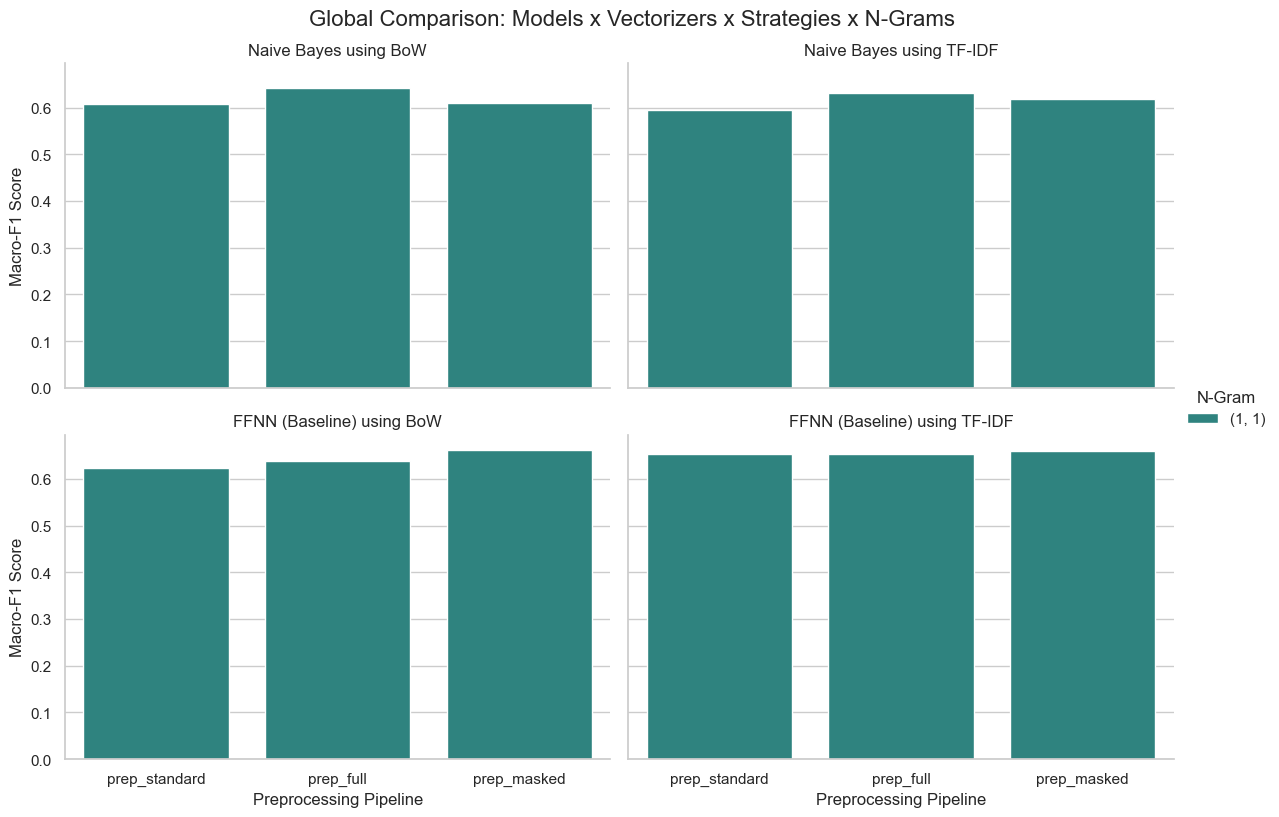


========================= FEATURE SIZE MATRIX =========================
Strategy           prep_full  prep_masked  prep_standard
Vectorizer N-Gram                                       
BoW        (1, 1)     8859.0       6697.0         6870.0
TF-IDF     (1, 1)     8859.0       6697.0         6870.0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder

# --- Evaluation Function ---
def evaluate_model(y_true, y_pred, model_display_name, classes):
    print(f"\n================ {model_display_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    # Plot Confusion Matrix (FIX: Removed labels=classes to prevent integer/string mismatch)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'CM: {model_display_name}', fontsize=10)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


# --- Data Loading and Encoding ---
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])
classes_multiclass = label_encoder.classes_  # Keeps string names for display

# Prepare columns (Assuming these preprocessing functions are defined in your environment)
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

# Setup Iterations
ngram_ranges = [
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 2), (2, 3), (2, 4), (2, 5),
    (3, 3), (3, 4), (3, 5),
    (4, 4), (4, 5),
    (5, 5)
]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []

models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Baseline)": MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        max_iter=50,
        early_stopping=True,
        random_state=42
    )
}

print("Starting the Grand Evaluation Loop. This may take a few minutes...")
feature_sizes = []

for strategy in strategies:
    print(f"\n---> Processing Strategy: {strategy.upper()}")

    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    smote_tomek = SMOTETomek(random_state=42)

    for ngram in ngram_ranges:
        print(f"     N-Gram: {ngram}")

        # --- 1. BoW Pipeline ---
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "BoW",
            "N-Gram": str(ngram),
            "Feature_Size": len(count_vect.get_feature_names_out())
        })

        # --- 2. TF-IDF Pipeline ---
        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "TF-IDF",
            "N-Gram": str(ngram),
            "Feature_Size": len(tfidf_vect.get_feature_names_out())
        })

        # --- 3. Test & Evaluate Models ---
        for model_name, model_instance in models.items():

            # --- BoW Evaluation ---
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "BoW",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow),
                "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            # Call your custom evaluation function for BoW
            bow_title = f"{model_name} (BoW | {strategy} | {ngram})"
            # evaluate_model(y_test, y_pred_bow, bow_title, classes_multiclass)

            # --- TF-IDF Evaluation ---
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "TF-IDF",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf),
                "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

            # Call your custom evaluation function for TF-IDF
            tfidf_title = f"{model_name} (TF-IDF | {strategy} | {ngram})"
            # evaluate_model(y_test, y_pred_tfidf, tfidf_title, classes_multiclass)

results_df = pd.DataFrame(results)
print("\nEvaluation Complete!")

# --- Global Aggregations ---
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Vectorizer', 'N-Gram'],
    columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=results_df,
    x='Strategy',
    y='Macro-F1',
    hue='N-Gram',
    col='Vectorizer',
    row='Model',
    kind='bar',
    palette="viridis",
    height=4,
    aspect=1.5
)
g.fig.suptitle("Global Comparison: Models x Vectorizers x Strategies x N-Grams", y=1.02, fontsize=16)
g.set_titles("{row_name} using {col_name}")
g.set_axis_labels("Preprocessing Pipeline", "Macro-F1 Score")
plt.show()

feature_sizes_df = pd.DataFrame(feature_sizes)
feature_pivot = pd.pivot_table(
    feature_sizes_df,
    values="Feature_Size",
    index=["Vectorizer", "N-Gram"],
    columns=["Strategy"]
)

print("\n========================= FEATURE SIZE MATRIX =========================")
print(feature_pivot)
print("=====================================================================")


In [7]:
import pprint
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pprint.pprint(df["prep_masked"])

from collections import Counter
import pprint

# Alle Wörter aus der Spalte "prep_full" in eine Liste umwandeln
all_words = []
for text in df["prep_full"]:
    if isinstance(text, str):  # Überprüfen, ob der Eintrag ein String ist
        words = text.split()  # Text in Wörter aufteilen
        all_words.extend(words)  # Wörter zur Liste hinzufügen

# Häufigkeit der Wörter zählen
word_counts = Counter(all_words)

# Die 50 häufigsten Wörter extrahieren
most_common_words = word_counts.most_common(100)

# Ergebnis anzeigen
pprint.pprint(most_common_words)


0                                                                                                                                                                                                                                                                                                      accord gran compani no plan move product russia although compani grow
1                                                                                                                                                                                                                                       technopoli plan develop stage area no less [NUMBER_MARKER] squar meter order host compani work comput technolog telecommun statement
2                                                                                                                                                                                                                    intern electron industri compani elcoteq laid ten employe

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

def evaluate_model(y_true, y_pred, model_name, classes):
    print(f"\n================ {model_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


In [ ]:
# simple bow and tfidf test
classes_multiclass = sorted(list(y_train.unique()))

feature_size = None
count_vect = CountVectorizer(max_features=feature_size, ngram_range=(2,3))

X_train_bow = count_vect.fit_transform(X_train_raw)
X_test_bow = count_vect.transform(X_test_raw)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

evaluate_model(y_test, y_pred_nb_bow, "Naive Bayes (boW)", classes_multiclass)

tfidf_vect = TfidfVectorizer(max_features=feature_size, token_pattern=r'(?u)\[?\b\w[-\w\.]*\b\]?')
X_train_tfidf = tfidf_vect.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vect.transform(X_test_raw)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_nb_tfidf, "Naive Bayes (TF-IDF)", classes_multiclass)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 9.4 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
print("\n========== PHASE 2: GRID SEARCH ON THE WINNING COMBINATION ==========")

# 1. Re-isolate the winning data configuration
BEST_STRATEGY = "prep_masked" # Change this based on your plot results
BEST_NGRAM = (1, 2)         # Change this based on your plot results

df_winner = df.dropna(subset=[BEST_STRATEGY, TARGET_COL]).reset_index(drop=True)
X_train_win, X_test_win, y_train_win, y_test_win = train_test_split(
    df_winner[BEST_STRATEGY], df_winner[TARGET_COL],
    test_size=0.20, random_state=42, stratify=df_winner[TARGET_COL]
)

# Apply winning vectorizer (assuming TF-IDF won)
final_vect = TfidfVectorizer(ngram_range=BEST_NGRAM, token_pattern=custom_token_pattern)
X_train_final = final_vect.fit_transform(X_train_win)
X_test_final = final_vect.transform(X_test_win)

# 2. Your Grid Search Logic
param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (32, 32), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'], # Note: lbfgs is removed here as it scales poorly on large sparse text matrices
    'alpha': [0.0001, 0.001, 0.01],
    'batch_size': [16, 32],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [20, 50, 100],
    'early_stopping': [True],
    'validation_fraction': [0.1],
    'random_state': [42]
}

mlp = MLPClassifier()
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3,                # Reduced from 5 to 3 to save immense time on sparse text matrices
    scoring='f1_macro',  # Changed to f1_macro to handle class imbalances
    n_jobs=-1,
    verbose=2
)

print(f"Executing Grid Search on {X_train_final.shape[0]} samples and {X_train_final.shape[1]} features...")
grid_search.fit(X_train_final, y_train_win)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

# 3. Final Evaluation
best_mlp = grid_search.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_final)

# (Reusing your evaluate_model function)
evaluate_model(y_test_win, y_pred_mlp, f"Tuned FFNN ({BEST_STRATEGY}, TF-IDF, {BEST_NGRAM})", classes_multiclass)
